In [ ]:
import torch
import torch.nn.functional as F
import lm_eval
from lm_eval.api.model import LM
from lm_eval.api.registry import register_model
from ddp_worker import GPT, vocab_size, vocab_to_id, bpe_ranks, id_to_vocab
import tokenizer

@register_model("my_custom_lm")
class MyCustomLMEval(LM):
    def __init__(self, checkpoint_path, tokenizer_path, batch_size=1, device="cuda", max_batch_size=None, **kwargs):
        super().__init__()
        self.device = torch.device(device)
        self._device = torch.device(device if torch.cuda.is_available() else "cpu")
        self._batch_size = int(batch_size) if (batch_size and batch_size != "auto") else 1
        self._max_length = 1024
        self.vocab_to_id = vocab_to_id
        self.bpe_ranks = bpe_ranks
        self.model = GPT(vocab_size=vocab_size, max_seq_len=1024, d_model=1024, heads=16, num_layers=16)
        self.model.load_state_dict(torch.load(checkpoint_path, map_location=self.device))
        self.model.eval().to(self.device)
    @property
    def device(self):
        return self._device

    @property
    def max_length(self):
        return self._max_length

    @property
    def batch_size(self):
        return self._batch_size
    def loglikelihood(self, requests, disable_tqdm=False):
        results = []

        for i in range(0, len(requests), self.batch_size):
            batch = requests[i : i + self.batch_size]

            tokenized_items = []
            max_len = 0

            for req in batch:
                context, continuation = req.args

                full_tokens = tokenizer.encode(
                    context + continuation, self.vocab_to_id, self.bpe_ranks
                )
                ctx_tokens = tokenizer.encode(context, self.vocab_to_id, self.bpe_ranks)

                cont_tokens = full_tokens[len(ctx_tokens) :]
                if full_tokens[:len(ctx_tokens)] != ctx_tokens:
                    self.mismatch = getattr(self, "mismatch", 0) + 1
                    if self.mismatch <= 5:
                        print(repr(context[-40:]), repr(continuation),
                              repr(tokenizer.decode(cont_tokens, id_to_vocab)))
                if len(full_tokens) > self.max_length:
                    full_tokens = full_tokens[-self.max_length :]
                    ctx_len = len(full_tokens) - len(cont_tokens)
                else:
                    ctx_len = len(ctx_tokens)

                tokenized_items.append((ctx_len, cont_tokens, full_tokens))
                max_len = max(max_len, len(full_tokens))

            input_ids = torch.zeros(
                (len(batch), max_len), dtype=torch.long, device=self.device
            )
            for idx, (_, _, full_tokens) in enumerate(tokenized_items):
                input_ids[idx, : len(full_tokens)] = torch.tensor(
                    full_tokens, device=self.device
                )

            with torch.no_grad():
                logits = self.model(
                    input_ids
                )  # Shape: [batch_size, seq_len, vocab_size]
                log_probs = F.log_softmax(logits, dim=-1)

            for idx, (ctx_len, cont_tokens, _) in enumerate(tokenized_items):
                cont_len = len(cont_tokens)

                # Logit alignment: logits[ctx_len - 1] predicts full_tokens[ctx_len]
                start_idx = ctx_len - 1
                end_idx = start_idx + cont_len

                target_ids = torch.tensor(cont_tokens, device=self.device)
                item_log_probs = log_probs[
                    idx, start_idx:end_idx
                ]  # [cont_len, vocab_size]

                gathered = item_log_probs.gather(
                    1, target_ids.unsqueeze(1)
                ).squeeze(1)

                sum_log_prob = gathered.sum().item()
                is_greedy = (
                    (item_log_probs.argmax(dim=-1) == target_ids).all().item()
                )

                results.append((sum_log_prob, is_greedy))

        return results

    def loglikelihood_rolling(self, requests, disable_tqdm=False):
        results = []
        for req in requests:
            (string,) = req.args

            tokens = tokenizer.encode(string, vocab_to_id, bpe_ranks)
            if len(tokens) > self.max_length:
                tokens = tokens[-self.max_length:]

            input_ids = torch.tensor([tokens], device=self.device)

            with torch.no_grad():
                logits = self.model(input_ids)
                log_probs = F.log_softmax(logits[:, :-1], dim=-1)
                targets = input_ids[:, 1:]
                nll = F.nll_loss(log_probs.view(-1, log_probs.size(-1)), targets.view(-1), reduction="sum")

            results.append(-nll.item())

        return results

    def generate_until(self, requests, disable_tqdm=False):
        raise NotImplementedError("generate_until is not implemented for this custom model wrapper.")


    @device.setter
    def device(self, value):
        self._device = value

In [ ]:
if __name__ == "__main__":
    lm = MyCustomLMEval(checkpoint_path="./gpt300m_bf16.pt", tokenizer_path="", batch_size=16, device="cuda:0")
    results = lm_eval.simple_evaluate(
        model=lm,
        tasks=["hellaswag", "lambada_openai"],
        batch_size=16,
    )
    print("tokenization mismatches:", getattr(lm, "mismatch", 0))
    print(lm_eval.utils.make_table(results))

In [ ]:
import torch, torch.nn.functional as F, numpy as np
from ddp_worker import GPT, vocab_size

model = GPT(vocab_size=vocab_size, max_seq_len=1024, d_model=1024, heads=16, num_layers=16)
model.load_state_dict(torch.load("gpt300m_bf16.pt", map_location="cpu"))
model = model.float().cuda().eval()

data = np.memmap("dataset.bin", dtype=np.int32, mode="r")
n_seq, losses = 200, []
start = len(data) - (n_seq + 1) * 1024
for i in range(n_seq):
    chunk = torch.from_numpy(data[start + i*1024 : start + i*1024 + 1025].astype(np.int64)).cuda()
    x, y = chunk[:-1].unsqueeze(0), chunk[1:].unsqueeze(0)
    with torch.no_grad():
        losses.append(F.cross_entropy(model(x)[0], y[0]).item())
print("mean loss:", sum(losses)/len(losses))

# Loss
Demonstration of loss during training of the model.

Initially development of the model yielded unruly results, an excerpt viewable in the dropdown menu. The learning rate graph provided shows the learning rate from start to finish of the latest model. The break inside of it is a lapse of data from the period. Training crashed at ~4.6B tokens processed. After, improved data tracking was added. Information regarding learning rate before 4.6B tokens are backwards calculations, not logged directly from the model.
<details>
<summary> Previous version early-training logs </summary>
Epoch [1/5] | Active Tensors: 6100MB | Reserved Pool: 19232MBStep [11200/1200268] | Loss: 7.4332 | Speed: 3.51 st/s (43112 tok/s) | ETA Epoch: 94:08:35 | Peak VRAM: 18439MB
TARGET BATCH SAMPLE :
" Substance use to cope with stigma in healthcare among U.S. female–but-male trans masculine adults . LGBT Health, 2, 324 – 332 . doi:10.1080/lgbt.2015..."
MODEL PREDICTION    :
",,. the. the. the. the of and,,,,,, ,, the, the, the, ,,,,,,, ,,  , ,    , a   ,  ,,, the the of of , the, the,. ,        .  the, . ,,,, a. , a.  ,  t..."

Epoch [1/5] | Active Tensors: 7247MB | Reserved Pool: 19232MBStep [11250/1200268] | Loss: 7.6425 | Speed: 3.56 st/s (43797 tok/s) | ETA Epoch: 92:40:01 | Peak VRAM: 18439MB
TARGET BATCH SAMPLE :
" but you’re not getting much to help right now. McDonagh has the highest trade value with two playoff runs for the team getting him, and he’s a guy th..."
MODEL PREDICTION    :
"  the, not, to. be... , a time,.. the... the time. a. and the was a time. time. be to be that. the to the you is to the time.  have the, the have that..."

Epoch [1/5] | Active Tensors: 7247MB | Reserved Pool: 19232MBStep [11300/1200268] | Loss: 8.0747 | Speed: 3.56 st/s (43752 tok/s) | ETA Epoch: 92:45:26 | Peak VRAM: 18439MB
TARGET BATCH SAMPLE :
" diese sich weit über Europa hinaus zu einem Standard entwickelt, an dem sich Staaten und Regionen vor allem in Asien, Nord- und Südamerika orientiere..."
MODEL PREDICTION    :
".....,..... a,,,,...,. the a, and, .,,,,.   ,,,,.,,,.......... .,, de de,,.. de,,....... , de,, de,,, de,.,.. de,,.. de de........ . de,...,............."

Epoch [1/5] | Active Tensors: 7247MB | Reserved Pool: 19232MBStep [11350/1200268] | Loss: 8.0026 | Speed: 3.56 st/s (43720 tok/s) | ETA Epoch: 92:49:18 | Peak VRAM: 18439MB
TARGET BATCH SAMPLE :
" went on to suggest that the court is more likely to greatly weaken the right to abortion by allowing more state restrictions on it.  "The states are ..."
MODEL PREDICTION    :
" I. the to. the time of a than to be, the time of the. the the of of and the.    time that the a, the of of the, is be the new, a to the to said said...."

Epoch [1/5] | Active Tensors: 6100MB | Reserved Pool: 19232MBStep [11400/1200268] | Loss: 7.5473 | Speed: 3.50 st/s (42973 tok/s) | ETA Epoch: 94:25:51 | Peak VRAM: 18439MB
TARGET BATCH SAMPLE :
",000  Monroe County Aer言x – 30,000  Northeast Regional (Gads MEP) – 30,000  Ozark Blackwell Field – 30,000  Pratt�е-Grouby Field – 30,000  Scottsboro ..."
MODEL PREDICTION    :
",,         ,,  .,   ,  ,,  ,,,, ,,  .,,,, , ,,  ,  , ,,  ,,,,,,  ,,  , ,, ,,  , , ,,  ,,,, ,,  ,, ,,  ,,,,  ,,   have in,,,,,  ,,  ,,, ,,  ,, ,, ,,   ..."

Epoch [1/5] | Active Tensors: 7247MB | Reserved Pool: 19232MBStep [11450/1200268] | Loss: 7.3053 | Speed: 3.57 st/s (43919 tok/s) | ETA Epoch: 92:23:40 | Peak VRAM: 18439MB
TARGET BATCH SAMPLE :
" little button on the right top bar of browser interface, also can have a options page, usually loaded as a pop-up, where we are able to adjust extens..."
MODEL PREDICTION    :
" a and and the,, of and the and and and a be a a to to and the and the first of and the are the to the to of and  the the that than, and, a of,, the t..."

Epoch [1/5] | Active Tensors: 7247MB | Reserved Pool: 19232MBStep [11500/1200268] | Loss: 7.7972 | Speed: 3.57 st/s (43819 tok/s) | ETA Epoch: 92:36:04 | Peak VRAM: 18439MB
TARGET BATCH SAMPLE :
" în ziua în care s-au comemorat eroii în întreaga țară, faptul că pe monumentul eroilor din localitate a apărut affairs nume nou… Alături de serraçãoț..."
MODEL PREDICTION    :
",,,,,,, a,.,, a,,, a,,,,,,,,,, a,, a,, a,, a,,, a a,,,,, a, a,, de,, a de,,,,, a,,,,,,, have,,,, ,,, a a,,,,, a a,,,., de,, a,,,, a,,,,,, , a,,,  The,..."

SAMPLE AUTOREGRESSIVE STRING:
"The                                                   "
Epoch [1/5] | Active Tensors: 7247MB | Reserved Pool: 19232MBStep [11550/1200268] | Loss: 8.0413 | Speed: 3.51 st/s (43143 tok/s) | ETA Epoch: 94:02:50 | Peak VRAM: 18439MB
TARGET BATCH SAMPLE :
" a cada dois dias, para economizar água, o que costuma ser uma prática muito comum. E é até conhecido o fato de que alguns hotéis deixam o mesmo edred..."
MODEL PREDICTION    :
", a,,, and de,,,, de de,,, de,,, , de,, de, de de,,,,, de,,,,,,, de de, de, ,,, a de de,,,, de de de de,, de,,, de de, de de,  ,, a a,,   ,, The have ..."

</details>



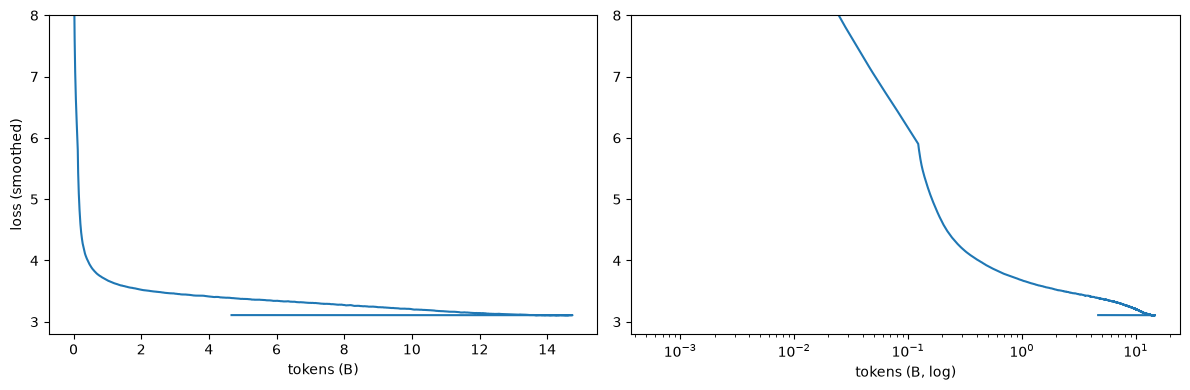

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

nb = pd.read_csv("logs/notebook_merged.csv")
live = pd.read_csv("logs/metrics.csv")          # post-resume, has grad norms
df = pd.concat([nb, live]).drop_duplicates("micro_step", keep="last").sort_values("micro_step")
df["smooth"] = df["loss_avg"].rolling(200, min_periods=1).mean()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(df.tokens / 1e9, df.smooth); ax[0].set_ylim(2.8, 8)
ax[0].set_xlabel("tokens (B)"); ax[0].set_ylabel("loss (smoothed)")
ax[1].plot(df.tokens / 1e9, df.smooth); ax[1].set_xscale("log"); ax[1].set_ylim(2.8, 8)
ax[1].set_xlabel("tokens (B, log)")
plt.tight_layout(); plt.savefig("figures/loss_curve.png", dpi=150)

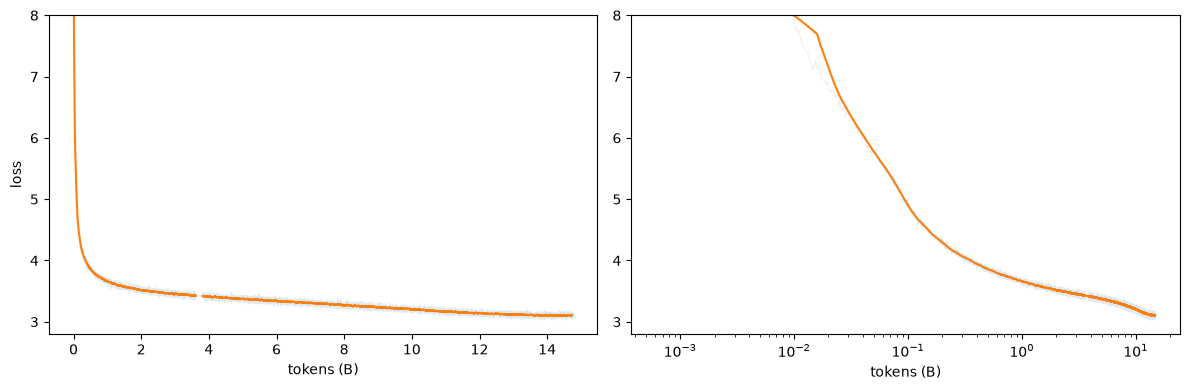

In [6]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

nb = pd.read_csv("notebook_merged.csv")
live = pd.read_csv("metrics.csv")
df = (pd.concat([nb, live])
        .dropna(subset=["micro_step"])                       # kills the stray row
        .drop_duplicates("micro_step", keep="last")
        .sort_values("micro_step")
        .reset_index(drop=True))

gap = df.micro_step.diff() > 200                             # normal spacing is 50
df["smooth"] = df.loss_avg.rolling(50, center=True, min_periods=10).mean()
df.loc[gap, ["smooth", "loss_avg"]] = np.nan                 # break the line at the gap

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for a in ax:
    a.plot(df.tokens/1e9, df.loss_avg, alpha=0.15, lw=0.5)   # raw
    a.plot(df.tokens/1e9, df.smooth)
    a.set_ylim(2.8, 8); a.set_xlabel("tokens (B)")
ax[1].set_xscale("log")
ax[0].set_ylabel("loss")
plt.tight_layout(); plt.savefig("loss_curve.png", dpi=150)

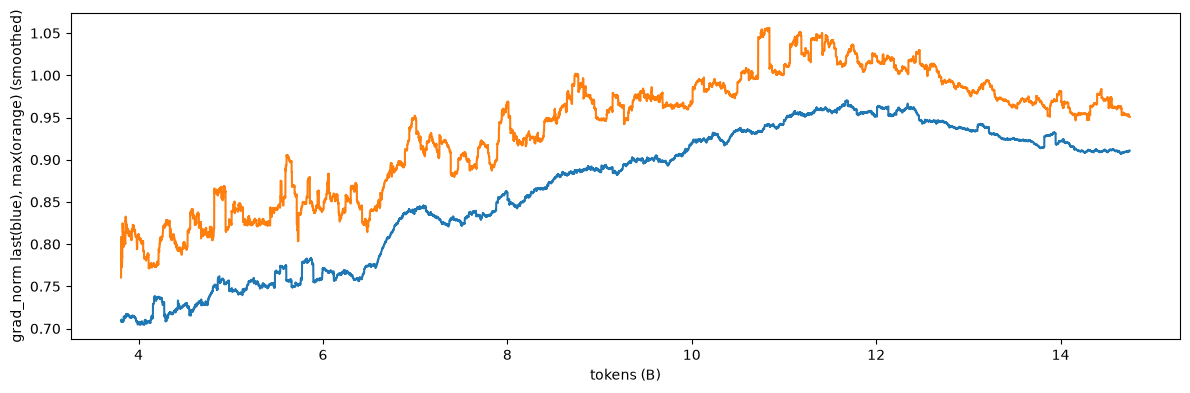

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

nb = pd.read_csv("logs/notebook_merged.csv")
live = pd.read_csv("logs/metrics.csv")          # post-resume, has grad norms
df = live.dropna().sort_values("micro_step").reset_index(drop=True)
df["smooth"] = df["grad_norm_last"].rolling(200, center=True, min_periods=10).mean()
df["smooth_max"] = df["grad_norm_max"].rolling(200, min_periods=1).mean()

fig, ax = plt.subplots(1, 1, figsize=(12, 4))
ax.plot(df.tokens / 1e9, df.smooth)
ax.plot(df.tokens / 1e9, df.smooth_max, color="#ff7f0e",)
ax.set_xlabel("tokens (B)"); ax.set_ylabel("grad_norm last(blue), max(orange) (smoothed)")
plt.tight_layout(); plt.savefig("figures/grad_norm_curve.png", dpi=150)

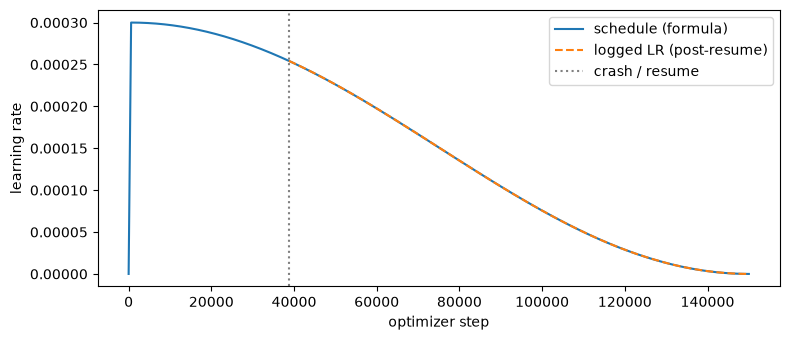

In [11]:
import math, numpy as np, matplotlib.pyplot as plt

def lr_at(opt_step, W=600, total=150033, peak=3e-4):
    if opt_step < W:
        return peak * opt_step / W
    p = (opt_step - W) / (total - W)
    return peak * 0.5 * (1 + math.cos(math.pi * p))

steps = np.arange(0, 150034, 100)
plt.figure(figsize=(8, 3.5))
plt.plot(steps, [lr_at(s) for s in steps], label="schedule (formula)")

live = df[df.grad_norm_last.notna()]
plt.plot(live.opt_step, live.lr, "--", label="logged LR (post-resume)")

plt.axvline(live.opt_step.min(), ls=":", c="gray", label="crash / resume")
plt.xlabel("optimizer step"); plt.ylabel("learning rate"); plt.legend()
plt.tight_layout(); plt.savefig("lr_schedule.png", dpi=150)